In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("train.csv")


In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


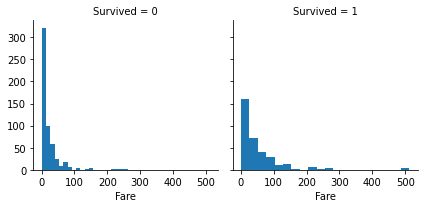

In [3]:
# facetgrid로 outlier 데이터 볼 수 있다. --> correcting
graph = sns.FacetGrid(df, col="Survived")
graph.map(plt.hist, "Fare", bins=20)

In [4]:
df.loc[df["Fare"] > 400, "Fare"] = df["Fare"].median()
# outlier 처리

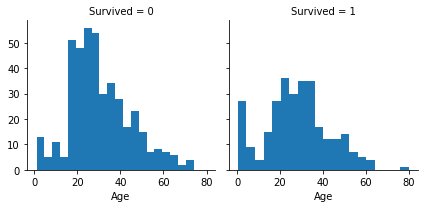

In [5]:
graph_age = sns.FacetGrid(df, col="Survived")
graph_age.map(plt.hist, "Age", bins=20)

In [6]:
df.loc[df["Age"]>70, "Age"] = 70

In [7]:
# Completing
# No Values

In [8]:
for column in df:
    print(column, ": ", df[column].isnull().sum()) #null column 개수 출력

PassengerId :  0
Survived :  0
Pclass :  0
Name :  0
Sex :  0
Age :  177
SibSp :  0
Parch :  0
Ticket :  0
Fare :  0
Cabin :  687
Embarked :  2


In [9]:
df["Age"].fillna(df["Age"].median(), inplace=True) # inplace: Save values

In [10]:
for column in df:
    print(column, ": ", df[column].isnull().sum()) #null column 개수 출력

PassengerId :  0
Survived :  0
Pclass :  0
Name :  0
Sex :  0
Age :  0
SibSp :  0
Parch :  0
Ticket :  0
Fare :  0
Cabin :  687
Embarked :  2


In [11]:
print(df["Embarked"].value_counts()) # number of different values

S    644
C    168
Q     77
Name: Embarked, dtype: int64


In [12]:
print(df["Pclass"].value_counts()) # number of different values

3    491
1    216
2    184
Name: Pclass, dtype: int64


In [13]:
df["Embarked"].fillna("S", inplace=True)

In [14]:
del df["Cabin"]

In [15]:
for column in df:
    print(column, ": ", df[column].isnull().sum()) 

PassengerId :  0
Survived :  0
Pclass :  0
Name :  0
Sex :  0
Age :  0
SibSp :  0
Parch :  0
Ticket :  0
Fare :  0
Embarked :  0


In [16]:
# Creating
# feature engineering

In [17]:
df["Name"].sample(20)

3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
635                                    Davis, Miss. Mary
281                     Olsson, Mr. Nils Johan Goransson
260                                    Smith, Mr. Thomas
497                      Shellard, Mr. Frederick William
119                    Andersson, Miss. Ellis Anna Maria
615                                  Herman, Miss. Alice
209                                     Blank, Mr. Henry
724                        Chambers, Mr. Norman Campbell
665                                   Hickman, Mr. Lewis
850              Andersson, Master. Sigvard Harald Elias
235                         Harknett, Miss. Alice Phoebe
641                                 Sagesser, Mlle. Emma
844                                  Culumovic, Mr. Jeso
26                               Emir, Mr. Farred Chehab
734                         Troupiansky, Mr. Moses Aaron
141                             Nysten, Miss. Anna Sofia
765                 Hogeboom, M

In [18]:
def get_title(name):
    if "." in name:
        return name.split(",")[1].split('.')[0].strip() # Miss or Mr 등 반환
    else:
        return "No title in name"
    

In [19]:
titles = set([x for x in df.Name.map(lambda x: get_title(x))]) #functional programming

In [20]:
print(titles)

{'Ms', 'Mrs', 'Rev', 'Major', 'Sir', 'Master', 'Don', 'Mr', 'Mlle', 'Col', 'Capt', 'the Countess', 'Jonkheer', 'Dr', 'Lady', 'Miss', 'Mme'}


In [21]:
def shorter_titles(x):
    title = x["Title"]
    if title in ["Capt", "Col", "Major"]:
        return "Officer"
    elif title in ["Jonkheer","Don","the Countess","Dona","Lady",'Str']:
        return "Royalty"
    elif title == "Mme":
        return "Mrs"
    elif title in ["Mlle", "Ms"]:
        return "Miss"
    else:
        return title

In [22]:
df["Title"] = df['Name'].map(lambda x: get_title(x))

In [23]:
df["Title"] = df.apply(shorter_titles, axis=1)

In [24]:
print(df.Title.value_counts())

Mr         517
Miss       185
Mrs        126
Master      40
Dr           7
Rev          6
Officer      5
Royalty      4
Sir          1
Name: Title, dtype: int64


In [25]:
df.drop("Name", axis=1, inplace=True) # del df["Name"]

In [26]:
df.sample(20)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
270,271,0,1,male,28.0,0,0,113798,31.0000,S,Mr
230,231,1,1,female,35.0,1,0,36973,83.4750,S,Mrs
16,17,0,3,male,2.0,4,1,382652,29.1250,Q,Master
656,657,0,3,male,28.0,0,0,349223,7.8958,S,Mr
680,681,0,3,female,28.0,0,0,330935,8.1375,Q,Miss
319,320,1,1,female,40.0,1,1,16966,134.5000,C,Mrs
703,704,0,3,male,25.0,0,0,36864,7.7417,Q,Mr
738,739,0,3,male,28.0,0,0,349201,7.8958,S,Mr
69,70,0,3,male,26.0,2,0,315151,8.6625,S,Mr
356,357,1,1,female,22.0,0,1,113505,55.0000,S,Miss


In [27]:
# Converting

In [28]:
df.Sex.replace(('male','female'), (0,1), inplace=True)


In [29]:
df.Embarked.value_counts()

S    646
C    168
Q     77
Name: Embarked, dtype: int64

In [30]:
df.Sex.replace(('S','C', 'Q'), (0,1,2), inplace=True) # 순서는 중요하지 않은 변수

In [31]:
df.Title.value_counts()

Mr         517
Miss       185
Mrs        126
Master      40
Dr           7
Rev          6
Officer      5
Royalty      4
Sir          1
Name: Title, dtype: int64

In [32]:
df.Sex.replace(('Mr','Miss','Mrs','Master','Dr','Rev','Officer','Royalty','Sir'), (0,1,2,3,4,5,6,7,8), inplace=True)


In [33]:
df.sample(20)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
869,870,1,3,0,4.0,1,1,347742,11.1333,S,Master
759,760,1,1,1,33.0,0,0,110152,86.5000,S,Royalty
399,400,1,2,1,28.0,0,0,240929,12.6500,S,Mrs
113,114,0,3,1,20.0,1,0,4136,9.8250,S,Miss
666,667,0,2,0,25.0,0,0,234686,13.0000,S,Mr
204,205,1,3,0,18.0,0,0,A/5 3540,8.0500,S,Mr
316,317,1,2,1,24.0,1,0,244367,26.0000,S,Mrs
583,584,0,1,0,36.0,0,0,13049,40.1250,C,Mr
260,261,0,3,0,28.0,0,0,384461,7.7500,Q,Mr
61,62,1,1,1,38.0,0,0,113572,80.0000,S,Miss
